# Cognitive State Model Pipeline

This notebook preprocesses the raw EEG data using the project code in `src`, trains each implemented model type, and reports metrics with plots.

## 1. Setup

Run this notebook from anywhere. The first code cell finds the project root, adds `src` to the Python path, and switches the working directory to the repository root so the existing modules can use their default `Data/...` paths.

In [5]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_ROOT)

DATA_RAW = PROJECT_ROOT / "Data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "Data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: "fatigued", 1: "impulsive", 2: "careful", 3: "focused"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {DATA_RAW}")
print(f"Processed data path: {DATA_PROCESSED}")

Project root: c:\Users\Chris\.vscode\Repositories\AI-Interpretation-on-Cognitive-States
Raw data path: c:\Users\Chris\.vscode\Repositories\AI-Interpretation-on-Cognitive-States\Data\raw
Processed data path: c:\Users\Chris\.vscode\Repositories\AI-Interpretation-on-Cognitive-States\Data\processed


In [6]:
import importlib

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit, LeaveOneGroupOut, StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler

import preprocessing
import data_loader
import decision_tree
import hmm_model
import cnn_model

# Notebooks keep imported modules cached between runs. Reload project modules
# so edits in src are actually used without restarting the kernel.
preprocessing = importlib.reload(preprocessing)
data_loader = importlib.reload(data_loader)
decision_tree = importlib.reload(decision_tree)
hmm_model = importlib.reload(hmm_model)
cnn_model = importlib.reload(cnn_model)

EEGPreprocessor = preprocessing.EEGPreprocessor
load_processed_data = data_loader.load_processed_data
build_decision_tree = decision_tree.build_decision_tree
train_state_hmms = hmm_model.train_state_hmms
predict_hmm = hmm_model.predict_hmm
EEGFeatureCNN = cnn_model.EEGFeatureCNN
EEGFeatureDataset = cnn_model.EEGFeatureDataset
train_model = cnn_model.train_model
evaluate_model = cnn_model.evaluate_model

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader
    from sklearn.utils.class_weight import compute_class_weight
    TORCH_AVAILABLE = True
except Exception as exc:
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = exc
    print(f"PyTorch import failed, CNN section will be skipped: {exc}")

## 2. Configuration

In [7]:
# Rebuild X/y by default so existing arrays made with older preprocessing are not reused.
FORCE_PREPROCESS = True

# The released dataset contains both Experiment_1 and Experiment_2. Missing
# folders are skipped automatically by discover_subjects().
EXPERIMENTS = ["Experiment_1", "Experiment_2"]

USE_PHYSIO = False
TEST_SIZE = 0.20
RANDOM_STATE = 42
USE_SUBJECT_HELDOUT_SPLIT = True
RUN_BINARY_DIAGNOSTICS = True
RUN_LOSO_DIAGNOSTICS = True
RUN_LOSO_RANDOM_FOREST = False
RUN_PERSON_SPECIFIC_DIAGNOSTICS = True
RUN_RFE_DIAGNOSTICS = False

# Normalize each subject's feature distribution before model fitting. This is
# an unsupervised correction for person/device/contact offsets that otherwise
# dominate held-out-subject evaluation.
NORMALIZE_WITHIN_SUBJECT = True

# A shallow tree is more useful diagnostically here than an unconstrained tree,
# which overfits noisy subject-specific feature quirks.
DECISION_TREE_MAX_DEPTH = 6
# These are engineered feature vectors, not continuous per-subject time series.
# One HMM state per label behaves like a class-conditional Gaussian density and
# avoids fitting arbitrary latent transitions over shuffled rows.
HMM_COMPONENTS = 1
CNN_EPOCHS = 20
CNN_BATCH_SIZE = 64
CNN_LR = 1e-3

## 3. Preprocess Raw Data

This uses `EEGPreprocessor` from `src/preprocessing.py`. If `Data/processed/X_features.npy` and `Data/processed/y_labels.npy` already exist, the notebook loads them unless `FORCE_PREPROCESS` is set to `True`.

In [8]:
def discover_subjects(raw_dir, experiment):
    exp_path = Path(raw_dir) / experiment
    if not exp_path.exists():
        print(f"Missing raw data folder: {exp_path}")
        return []

    return sorted(
        path.name for path in exp_path.iterdir()
        if path.is_dir() and not path.name.startswith("Excluded")
    )


def build_processed_dataset(raw_dir=DATA_RAW, experiments=EXPERIMENTS, use_physio=USE_PHYSIO):
    preprocessor = EEGPreprocessor(str(raw_dir))
    all_X = []
    all_y = []
    all_subjects = []
    subject_rows = []
    all_trial_metadata = []

    for experiment in experiments:
        subjects = discover_subjects(raw_dir, experiment)
        print(f"\n{experiment}: found {len(subjects)} subjects")

        for subject in subjects:
            X_subject, y_subject, trial_df = preprocessor.process_subject(
                subject,
                experiment=experiment,
                use_physio=use_physio,
            )

            if X_subject is None or y_subject is None or len(X_subject) == 0:
                continue

            all_X.append(X_subject)
            all_y.append(y_subject)
            all_subjects.extend([f"{experiment}/{subject}"] * len(y_subject))

            if trial_df is not None and len(trial_df) >= len(y_subject):
                aligned_trials = trial_df.iloc[:len(y_subject)].copy().reset_index(drop=True)
                aligned_trials["experiment"] = experiment
                aligned_trials["subject"] = subject
                aligned_trials["subject_id"] = f"{experiment}/{subject}"
                aligned_trials["model_row"] = np.arange(len(y_subject))
                all_trial_metadata.append(aligned_trials)

            subject_rows.append({
                "experiment": experiment,
                "subject": subject,
                "samples": len(y_subject),
            })

    if not all_X:
        raise RuntimeError(
            "No subjects were processed. Download raw data first with `python download_all_data.py`, "
            "then rerun this notebook."
        )

    X = np.vstack(all_X).astype(np.float32)
    y = np.concatenate(all_y).astype(np.int32)
    subject_ids = np.array(all_subjects)
    subject_summary = pd.DataFrame(subject_rows)
    trial_metadata = pd.concat(all_trial_metadata, ignore_index=True) if all_trial_metadata else None

    np.save(DATA_PROCESSED / "X_features.npy", X)
    np.save(DATA_PROCESSED / "y_labels.npy", y)
    np.save(DATA_PROCESSED / "subject_ids.npy", subject_ids)
    subject_summary.to_csv(DATA_PROCESSED / "subject_summary.csv", index=False)
    if trial_metadata is not None:
        trial_metadata.to_csv(DATA_PROCESSED / "trial_metadata.csv", index=False)

    return X, y, subject_ids, subject_summary, trial_metadata


x_path = DATA_PROCESSED / "X_features.npy"
y_path = DATA_PROCESSED / "y_labels.npy"

if x_path.exists() and y_path.exists() and not FORCE_PREPROCESS:
    X, y = load_processed_data(str(DATA_PROCESSED))
    subject_ids_path = DATA_PROCESSED / "subject_ids.npy"
    summary_path = DATA_PROCESSED / "subject_summary.csv"
    metadata_path = DATA_PROCESSED / "trial_metadata.csv"
    subject_ids = np.load(subject_ids_path, allow_pickle=True) if subject_ids_path.exists() else None
    subject_summary = pd.read_csv(summary_path) if summary_path.exists() else None
    trial_metadata = pd.read_csv(metadata_path) if metadata_path.exists() else None
    print("Loaded existing processed arrays.")
else:
    X, y, subject_ids, subject_summary, trial_metadata = build_processed_dataset()
    print("Built and saved processed arrays.")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes present: {sorted(np.unique(y).tolist())}")


Experiment_1: found 10 subjects

Processing: Experiment_1/A1
  Found sessions: [101, 102, 103, 104]
  Total non-null trials: 1408
  Trials with RT > 0: 1405 (kept)
  Trials with RT = 0: 3 (filtered - no response)
  Response phases: {'stimulus': 1377, 'fixation': 28}
  Baseline correct trials: 337
  Baseline median RT (correct only): 332 ms
  Instruction-specific RT thresholds: 2
  Total trials with responses: 1405
  State distribution:
    0 (fatigued  ):   51 trials (3.6%)
    1 (impulsive ):   53 trials (3.8%)
    2 (careful   ):  597 trials (42.5%)
    3 (focused   ):  704 trials (50.1%)
  Loaded EEG: 1,298,136 rows

  Final dataset: 1405 samples × 183 features
  Class balance: {np.int32(0): np.int64(51), np.int32(1): np.int64(53), np.int32(2): np.int64(597), np.int32(3): np.int64(704)}

Processing: Experiment_1/A10
  Found sessions: [101, 102, 103, 104]
  Total non-null trials: 1408
  Trials with RT > 0: 1400 (kept)
  Trials with RT = 0: 8 (filtered - no response)
  Response phase

## 4. Dataset Overview

,state,samples
0,fatigued,1164
1,impulsive,1351
2,careful,8845
3,focused,12677


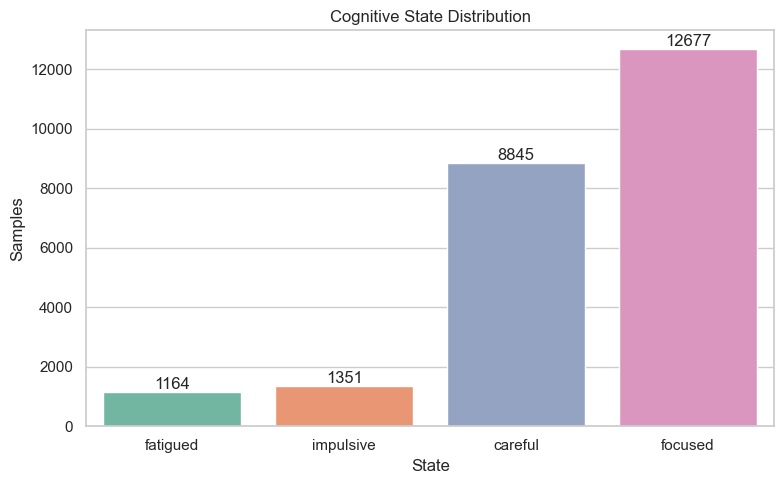

,experiment,subject,samples
0,Experiment_1,A1,1405
1,Experiment_1,A10,1400
2,Experiment_1,A2,1370
3,Experiment_1,A3,1388
4,Experiment_1,A4,1377
5,Experiment_1,A5,1384
6,Experiment_1,A6,1344
7,Experiment_1,A7,1395
8,Experiment_1,A8,1378
9,Experiment_1,A9,1385


,subject_id,samples,median_rt,mean_accuracy
0,Experiment_1/A1,1405,329.0,0.925979
1,Experiment_1/A10,1400,765.0,0.885714
2,Experiment_1/A2,1370,464.0,0.917518
3,Experiment_1/A3,1388,437.0,0.896974
4,Experiment_1/A4,1377,668.0,0.846768
5,Experiment_1/A5,1384,564.5,0.886561
6,Experiment_1/A6,1344,859.0,0.906250
7,Experiment_1/A7,1395,381.0,0.845161
8,Experiment_1/A8,1378,513.5,0.921626
9,Experiment_1/A9,1385,459.0,0.875812


state_label,careful,fatigued,focused,impulsive
subject_id,,,,
Experiment_1/A1,0.424911,0.036299,0.501068,0.037722
Experiment_1/A10,0.415000,0.077857,0.470714,0.036429
Experiment_1/A2,0.474453,0.051825,0.443066,0.030657
Experiment_1/A3,0.322046,0.054035,0.574928,0.048991
Experiment_1/A4,0.368192,0.070443,0.478577,0.082789
Experiment_1/A5,0.291908,0.048410,0.594653,0.065029
Experiment_1/A6,0.407738,0.046875,0.498512,0.046875
Experiment_1/A7,0.386380,0.062366,0.458781,0.092473
Experiment_1/A8,0.214804,0.020319,0.706821,0.058055


condition,CoffeeSession,NewMusicSession,NoAct,NoMusic,PerfumeSession,RelaxSession,StressSession
experiment,,,,,,,
Experiment_1,0,3465,0,3445,0,3457,3459
Experiment_2,3421,0,3386,0,3404,0,0


,experiment,condition,samples,mean_accuracy,median_rt,focused_rate,careful_rate,error_rate
0,Experiment_1,NewMusicSession,3465,0.908802,459.0,0.616162,0.292641,0.091198
1,Experiment_1,NoMusic,3445,0.885051,569.0,0.446444,0.438607,0.114949
2,Experiment_1,RelaxSession,3457,0.899335,534.0,0.533121,0.366213,0.100665
3,Experiment_1,StressSession,3459,0.869905,495.0,0.547846,0.322058,0.130095
4,Experiment_2,CoffeeSession,3421,0.876060,601.0,0.530254,0.345805,0.123940
5,Experiment_2,NoAct,3386,0.911105,661.0,0.459835,0.451270,0.088895
6,Experiment_2,PerfumeSession,3404,0.917744,608.0,0.556698,0.361046,0.082256


response_phase,fixation,stimulus
subject_id,,
Experiment_1/A1,0.019929,0.980071
Experiment_1/A10,0.942143,0.057857
Experiment_1/A2,0.375912,0.624088
Experiment_1/A3,0.369597,0.630403
Experiment_1/A4,0.790123,0.209877
Experiment_1/A5,0.631503,0.368497
Experiment_1/A6,0.952381,0.047619
Experiment_1/A7,0.146953,0.853047
Experiment_1/A8,0.512337,0.487663


In [9]:
label_counts = pd.Series(y).map(LABEL_NAMES).value_counts().reindex(LABEL_NAMES.values(), fill_value=0)
display(pd.DataFrame({"state": label_counts.index, "samples": label_counts.values}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax, palette="Set2")
ax.set_title("Cognitive State Distribution")
ax.set_xlabel("State")
ax.set_ylabel("Samples")
for idx, count in enumerate(label_counts.values):
    ax.text(idx, count, str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()

if subject_summary is not None:
    display(subject_summary)

if trial_metadata is not None and len(trial_metadata) == len(y):
    metadata_summary = trial_metadata.groupby("subject_id").agg(
        samples=("cognitive_state", "size"),
        median_rt=("reaction_time", "median"),
        mean_accuracy=("accuracy", "mean"),
    ).reset_index()
    display(metadata_summary)

    if "state_label" in trial_metadata.columns:
        state_by_subject = pd.crosstab(
            trial_metadata["subject_id"],
            trial_metadata["state_label"],
            normalize="index",
        )
        display(state_by_subject)

    if "condition" in trial_metadata.columns:
        condition_by_experiment = pd.crosstab(
            trial_metadata["experiment"],
            trial_metadata["condition"],
        )
        display(condition_by_experiment)

        condition_behavior = trial_metadata.groupby(["experiment", "condition"]).agg(
            samples=("cognitive_state", "size"),
            mean_accuracy=("accuracy", "mean"),
            median_rt=("reaction_time", "median"),
            focused_rate=("cognitive_state", lambda values: np.mean(values == 3)),
            careful_rate=("cognitive_state", lambda values: np.mean(values == 2)),
            error_rate=("accuracy", lambda values: np.mean(values < 0.5)),
        ).reset_index()
        display(condition_behavior)

    if "response_phase" in trial_metadata.columns:
        response_phase_table = pd.crosstab(
            trial_metadata["subject_id"],
            trial_metadata["response_phase"],
            normalize="index",
        )
        display(response_phase_table)

## 5. Shared Evaluation Helpers

In [10]:
def make_feature_names(num_features):
    channels = ["TP9", "AF7", "AF8", "TP10"]
    aggregate_features = [
        "delta", "theta", "alpha", "beta", "gamma",
        "rel_delta", "rel_theta", "rel_alpha", "rel_beta", "rel_gamma",
        "mean", "std", "skew", "kurtosis", "activity", "mobility", "complexity", "theta_beta_ratio",
    ]
    bands = ["delta", "theta", "alpha", "beta", "gamma"]
    tf_features = []
    for band in bands:
        tf_features.extend([
            f"tf_{band}_pre",
            f"tf_{band}_early",
            f"tf_{band}_late",
            f"tf_{band}_early_minus_pre",
            f"tf_{band}_late_minus_pre",
        ])
    per_channel = aggregate_features + tf_features
    names = [f"{channel}_{feature}" for channel in channels for feature in per_channel]
    names.append("frontal_alpha_asymmetry")

    for left_idx, left_channel in enumerate(channels):
        for right_channel in channels[left_idx:]:
            names.append(f"cov_{left_channel}_{right_channel}")

    if num_features > len(names):
        names.extend([f"physio_{idx}" for idx in range(num_features - len(names))])

    return names[:num_features]


def evaluate_predictions(model_name, y_true, y_pred):
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])).tolist())
    target_names = [LABEL_NAMES[label] for label in labels]
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )
    print(f"\n{model_name} classification report")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    y_true_array = np.asarray(y_true)
    y_pred_array = np.asarray(y_pred)
    abs_label_error = np.abs(y_true_array - y_pred_array)
    error_mask = y_true_array != y_pred_array
    adjacent_error_rate = float(np.mean(abs_label_error[error_mask] == 1)) if np.any(error_mask) else 0.0
    large_jump_error_rate = float(np.mean(abs_label_error[error_mask] >= 2)) if np.any(error_mask) else 0.0
    mean_abs_label_error = float(np.mean(abs_label_error))
    prediction_majority_rate = float(pd.Series(y_pred_array).value_counts(normalize=True).iloc[0])

    confusion_analysis = pd.DataFrame({
        "model": [model_name],
        "mean_abs_label_error": [mean_abs_label_error],
        "adjacent_error_rate_among_errors": [adjacent_error_rate],
        "large_jump_error_rate_among_errors": [large_jump_error_rate],
        "prediction_majority_rate": [prediction_majority_rate],
    })
    display(confusion_analysis)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

    prediction_records.append({
        "model": model_name,
        "y_true": y_true_array,
        "y_pred": y_pred_array,
    })

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mean_abs_label_error": mean_abs_label_error,
        "adjacent_error_rate": adjacent_error_rate,
        "large_jump_error_rate": large_jump_error_rate,
        "prediction_majority_rate": prediction_majority_rate,
        "report": report_dict,
        "y_true": y_true_array,
        "y_pred": y_pred_array,
    }


feature_names = make_feature_names(X.shape[1])

def feature_family(feature_name):
    if feature_name == "frontal_alpha_asymmetry":
        return "asymmetry"
    if feature_name.startswith("cov_"):
        return "covariance"
    if feature_name.startswith("physio_"):
        return "physio"
    suffix = feature_name.split("_", 1)[1]
    if suffix.startswith("tf_"):
        return "time_frequency"
    if suffix in {"delta", "theta", "alpha", "beta", "gamma", "rel_delta", "rel_theta", "rel_alpha", "rel_beta", "rel_gamma", "theta_beta_ratio"}:
        return "spectral"
    if suffix in {"activity", "mobility", "complexity"}:
        return "hjorth"
    return "statistical"


def summarize_importance_by_family(importance_df):
    family_df = importance_df.copy()
    family_df["family"] = family_df["feature"].map(feature_family)
    return family_df.groupby("family", as_index=False)["importance"].sum().sort_values("importance", ascending=False)

metrics = []
prediction_records = []

## 6. Feature Diagnostics

Before fitting models, check which feature families have any label association. This is descriptive only, not proof of generalization.

In [11]:
feature_diagnostics = []
for idx, name in enumerate(feature_names):
    values = X[:, idx]
    if np.std(values) < 1e-12:
        corr = 0.0
    else:
        corr = np.corrcoef(values, y)[0, 1]
        corr = 0.0 if np.isnan(corr) else corr
    feature_diagnostics.append({
        "feature": name,
        "family": feature_family(name),
        "abs_corr_with_label": abs(corr),
        "corr_with_label": corr,
        "std": float(np.std(values)),
    })

feature_diag_df = pd.DataFrame(feature_diagnostics).sort_values("abs_corr_with_label", ascending=False)
display(feature_diag_df.head(20))
display(feature_diag_df.groupby("family", as_index=False)["abs_corr_with_label"].mean().sort_values("abs_corr_with_label", ascending=False))

,feature,family,abs_corr_with_label,corr_with_label,std
63,AF7_tf_delta_late,time_frequency,0.100048,-0.100048,1.831405
68,AF7_tf_theta_late,time_frequency,0.099023,-0.099023,1.489950
44,AF7_theta,spectral,0.092649,-0.092649,1.728609
43,AF7_delta,spectral,0.092039,-0.092039,1.963364
57,AF7_activity,hjorth,0.085513,-0.085513,1.933212
54,AF7_std,statistical,0.085489,-0.085489,0.922787
45,AF7_alpha,spectral,0.082430,-0.082430,1.451794
39,TP9_tf_gamma_early,time_frequency,0.081425,-0.081425,0.532394
73,AF7_tf_alpha_late,time_frequency,0.080111,-0.080111,1.148589
72,AF7_tf_alpha_early,time_frequency,0.076576,-0.076576,1.235620


,family,abs_corr_with_label
0,asymmetry,0.056668
2,hjorth,0.038441
3,spectral,0.034637
5,time_frequency,0.028920
1,covariance,0.026111
4,statistical,0.021589


## 7. Train/Test Split

All models use the same split. By default this notebook uses a subject-held-out split when subject IDs are available. It can also normalize each subject's feature distribution before the train/test scaler to reduce person/device offsets.

In [12]:
def normalize_by_subject(X_values, groups):
    X_values = np.asarray(X_values, dtype=np.float32).copy()
    groups = np.asarray(groups)

    for group in np.unique(groups):
        mask = groups == group
        subject_X = X_values[mask]
        median = np.median(subject_X, axis=0)
        q1 = np.percentile(subject_X, 25, axis=0)
        q3 = np.percentile(subject_X, 75, axis=0)
        iqr = q3 - q1
        scale = np.where(iqr > 1e-6, iqr, np.std(subject_X, axis=0))
        scale = np.where(scale > 1e-6, scale, 1.0)
        X_values[mask] = (subject_X - median) / scale

    return X_values


X_model = X
if NORMALIZE_WITHIN_SUBJECT and subject_ids is not None and len(subject_ids) == len(y):
    X_model = normalize_by_subject(X, subject_ids)
    print("Applied within-subject robust feature normalization")

if USE_SUBJECT_HELDOUT_SPLIT and subject_ids is not None and len(subject_ids) == len(y):
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(X, y, groups=subject_ids))
    X_train_raw, X_test_raw = X_model[train_idx], X_model[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    train_subjects = sorted(set(subject_ids[train_idx]))
    test_subjects = sorted(set(subject_ids[test_idx]))
    print("Using subject-held-out split")
    print(f"Train subjects: {train_subjects}")
    print(f"Test subjects: {test_subjects}")
else:
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(
        indices,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    X_train_raw, X_test_raw = X_model[train_idx], X_model[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    print("Using stratified random trial split")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

split_counts = pd.DataFrame({
    "train": pd.Series(y_train).map(LABEL_NAMES).value_counts(),
    "test": pd.Series(y_test).map(LABEL_NAMES).value_counts(),
}).reindex(LABEL_NAMES.values()).fillna(0).astype(int)
display(split_counts)

Applied within-subject robust feature normalization
Using subject-held-out split
Train subjects: [np.str_('Experiment_1/A2'), np.str_('Experiment_1/A3'), np.str_('Experiment_1/A4'), np.str_('Experiment_1/A5'), np.str_('Experiment_1/A6'), np.str_('Experiment_1/A7'), np.str_('Experiment_1/A8'), np.str_('Experiment_1/A9'), np.str_('Experiment_2/B1'), np.str_('Experiment_2/B10'), np.str_('Experiment_2/B2'), np.str_('Experiment_2/B3'), np.str_('Experiment_2/B4'), np.str_('Experiment_2/B6'), np.str_('Experiment_2/B8'), np.str_('Experiment_2/B9')]
Test subjects: [np.str_('Experiment_1/A1'), np.str_('Experiment_1/A10'), np.str_('Experiment_2/B5'), np.str_('Experiment_2/B7')]
Train shape: (19211, 183)
Test shape: (4826, 183)


,train,test
fatigued,878,286
impulsive,1092,259
careful,6989,1856
focused,10252,2425


## 8. Feature Family Ablation

In [13]:
family_rows = []
families = sorted({feature_family(name) for name in feature_names})

for family in families:
    indices = [idx for idx, name in enumerate(feature_names) if feature_family(name) == family]
    if not indices:
        continue

    family_model = LogisticRegression(
        C=0.25,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    family_model.fit(X_train[:, indices], y_train)
    family_pred = family_model.predict(X_test[:, indices])
    family_rows.append({
        "family": family,
        "features": len(indices),
        "balanced_accuracy": balanced_accuracy_score(y_test, family_pred),
        "macro_f1": f1_score(y_test, family_pred, average="macro", zero_division=0),
        "accuracy": accuracy_score(y_test, family_pred),
    })

family_ablation_df = pd.DataFrame(family_rows).sort_values("balanced_accuracy", ascending=False)
display(family_ablation_df)

,family,features,balanced_accuracy,macro_f1,accuracy
4,statistical,16,0.249062,0.214436,0.295690
2,hjorth,12,0.247147,0.215159,0.300870
5,time_frequency,100,0.235887,0.202123,0.301699
0,asymmetry,1,0.232318,0.142586,0.209076
3,spectral,44,0.230381,0.205737,0.276419
1,covariance,10,0.228276,0.194707,0.243266


## 9. Majority Baseline


Majority Baseline classification report
              precision    recall  f1-score   support

    fatigued       0.00      0.00      0.00       286
   impulsive       0.00      0.00      0.00       259
     careful       0.00      0.00      0.00      1856
     focused       0.50      1.00      0.67      2425

    accuracy                           0.50      4826
   macro avg       0.13      0.25      0.17      4826
weighted avg       0.25      0.50      0.34      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Majority Baseline,0.669706,0.773011,0.226989,1.0


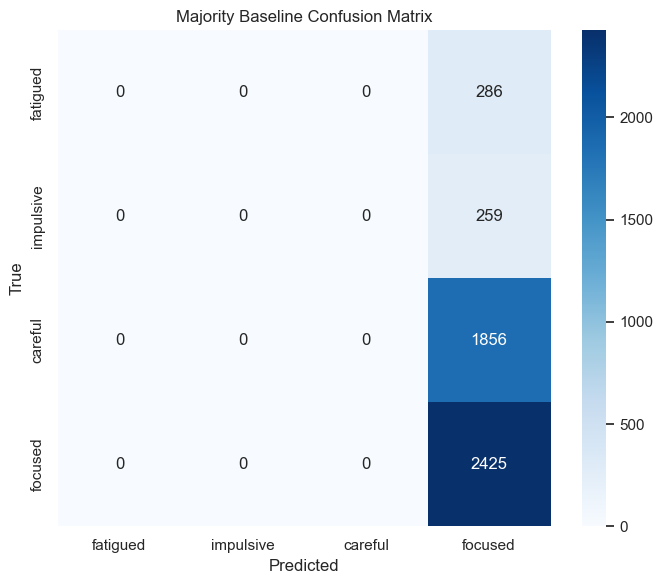

In [14]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
metrics.append(evaluate_predictions("Majority Baseline", y_test, baseline_pred))

## 10. Regularized Logistic Regression


Logistic Regression classification report
              precision    recall  f1-score   support

    fatigued       0.04      0.14      0.07       286
   impulsive       0.06      0.25      0.10       259
     careful       0.39      0.21      0.27      1856
     focused       0.49      0.38      0.43      2425

    accuracy                           0.29      4826
   macro avg       0.25      0.25      0.22      4826
weighted avg       0.40      0.29      0.33      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Logistic Regression,1.15976,0.540018,0.459982,0.391629


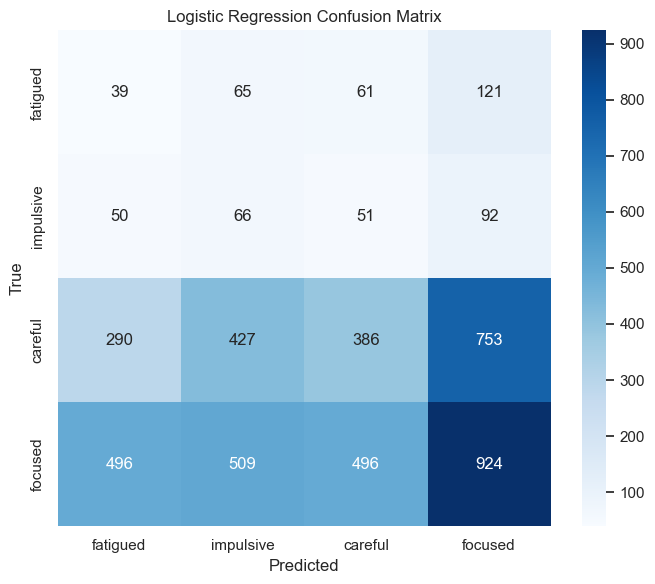

In [15]:
log_reg = LogisticRegression(
    C=0.25,
    max_iter=5000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_test)
metrics.append(evaluate_predictions("Logistic Regression", y_test, log_reg_pred))

## 11. Random Forest


Random Forest classification report
              precision    recall  f1-score   support

    fatigued       0.13      0.01      0.01       286
   impulsive       0.19      0.01      0.02       259
     careful       0.38      0.34      0.36      1856
     focused       0.51      0.66      0.58      2425

    accuracy                           0.46      4826
   macro avg       0.30      0.25      0.24      4826
weighted avg       0.42      0.46      0.43      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Random Forest,0.668462,0.827079,0.172921,0.65603


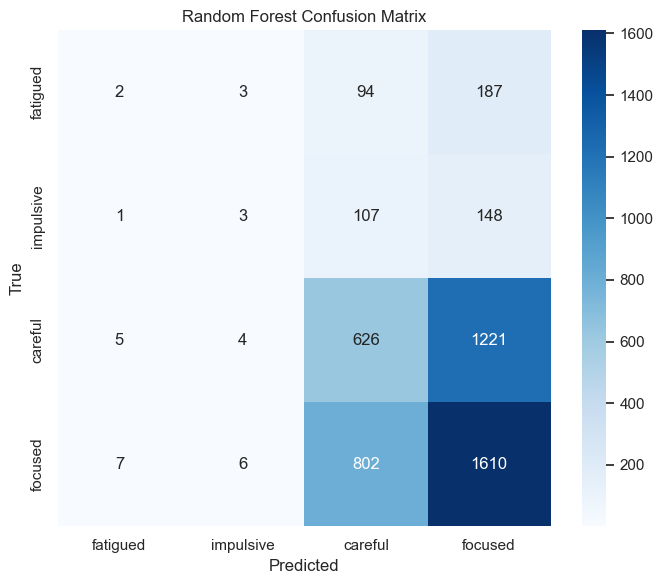

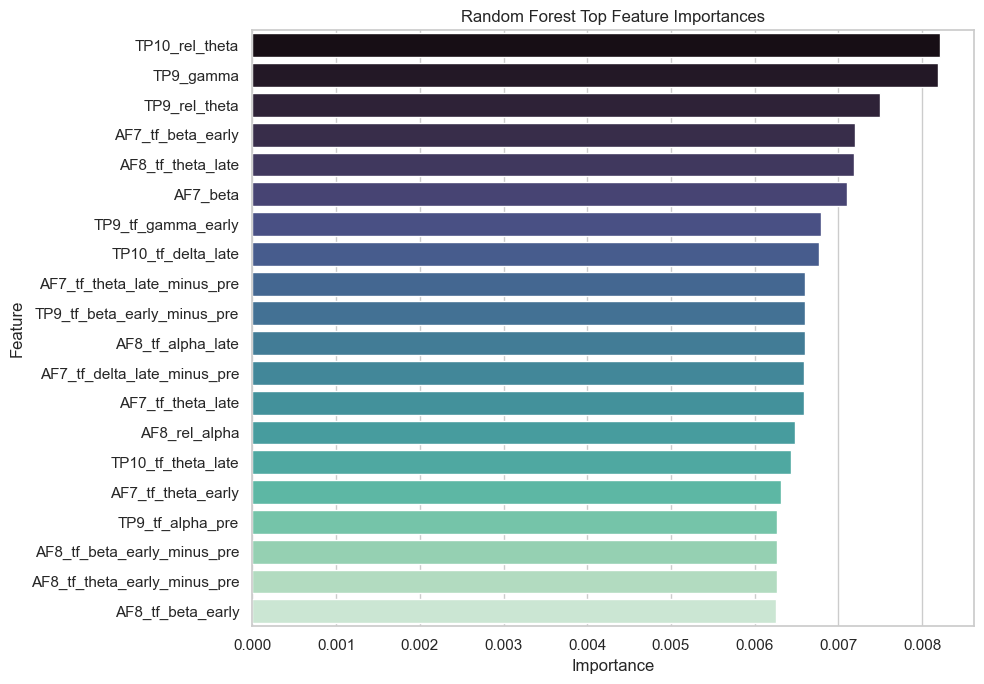

,feature,importance
135,TP10_rel_theta,0.008209
4,TP9_gamma,0.008188
6,TP9_rel_theta,0.007502
77,AF7_tf_beta_early,0.007201
111,AF8_tf_theta_late,0.007191
46,AF7_beta,0.007099
39,TP9_tf_gamma_early,0.006790
149,TP10_tf_delta_late,0.006762
70,AF7_tf_theta_late_minus_pre,0.006603
36,TP9_tf_beta_early_minus_pre,0.006602


,family,importance
5,time_frequency,0.559226
3,spectral,0.236470
4,statistical,0.085481
2,hjorth,0.056824
1,covariance,0.056361
0,asymmetry,0.005637


In [16]:
forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)
metrics.append(evaluate_predictions("Random Forest", y_test, forest_pred))

forest_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": forest.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=forest_importance, x="importance", y="feature", ax=ax, palette="mako")
ax.set_title("Random Forest Top Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(forest_importance)
display(summarize_importance_by_family(pd.DataFrame({
    "feature": feature_names,
    "importance": forest.feature_importances_,
})))

## 12. Decision Tree


Decision Tree classification report
              precision    recall  f1-score   support

    fatigued       0.06      0.40      0.10       286
   impulsive       0.05      0.32      0.09       259
     careful       0.32      0.05      0.08      1856
     focused       0.50      0.19      0.27      2425

    accuracy                           0.15      4826
   macro avg       0.23      0.24      0.13      4826
weighted avg       0.38      0.15      0.18      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Decision Tree,1.622669,0.335044,0.664956,0.410899


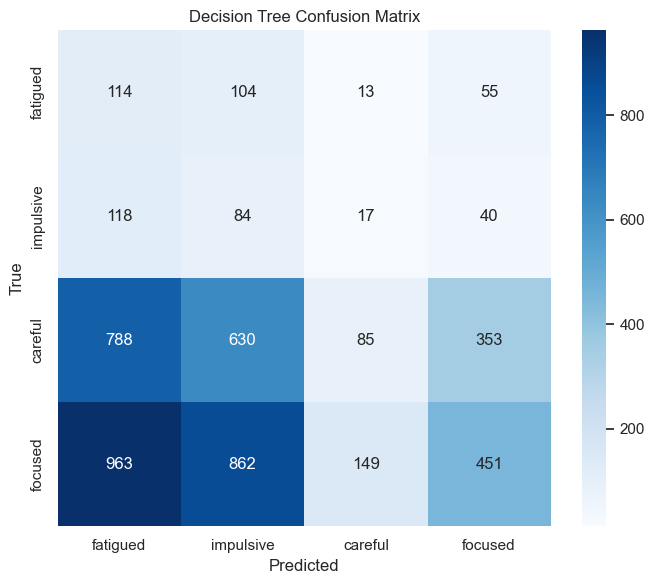

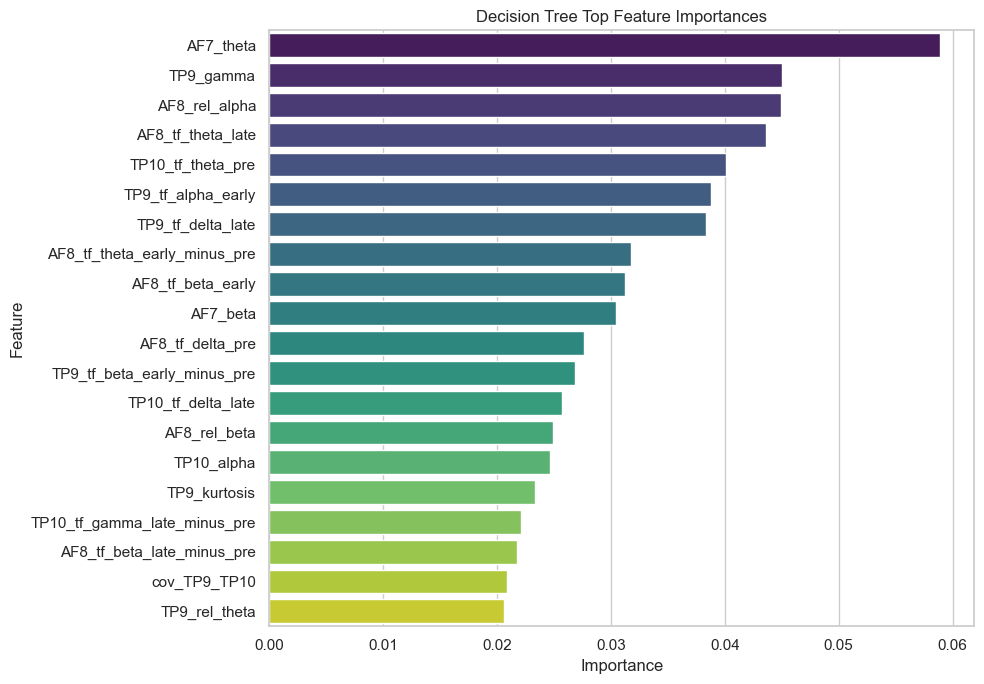

,feature,importance
44,AF7_theta,0.058935
4,TP9_gamma,0.045046
93,AF8_rel_alpha,0.044969
111,AF8_tf_theta_late,0.043652
152,TP10_tf_theta_pre,0.040099
29,TP9_tf_alpha_early,0.038803
20,TP9_tf_delta_late,0.038327
112,AF8_tf_theta_early_minus_pre,0.031732
120,AF8_tf_beta_early,0.031237
46,AF7_beta,0.030480


,family,importance
5,time_frequency,0.539496
3,spectral,0.337737
4,statistical,0.076995
1,covariance,0.045772
0,asymmetry,0.000000
2,hjorth,0.000000


In [17]:
tree = build_decision_tree(max_depth=DECISION_TREE_MAX_DEPTH, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

metrics.append(evaluate_predictions("Decision Tree", y_test, tree_pred))

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": tree.feature_importances_,
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importance, x="importance", y="feature", ax=ax, palette="viridis")
ax.set_title("Decision Tree Top Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance)
display(summarize_importance_by_family(pd.DataFrame({
    "feature": feature_names,
    "importance": tree.feature_importances_,
})))

## 13. Hidden Markov Models


Gaussian HMM classification report
              precision    recall  f1-score   support

    fatigued       0.06      0.11      0.08       286
   impulsive       0.05      0.05      0.05       259
     careful       0.37      0.07      0.12      1856
     focused       0.50      0.77      0.61      2425

    accuracy                           0.42      4826
   macro avg       0.25      0.25      0.21      4826
weighted avg       0.40      0.42      0.36      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Gaussian HMM,0.87816,0.646911,0.353089,0.77041


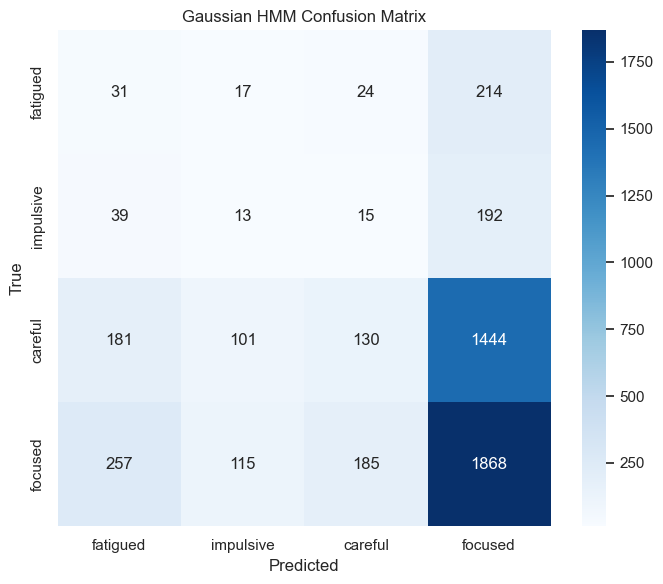

In [18]:
try:
    hmm_models = train_state_hmms(
        X_train,
        y_train,
        n_components=HMM_COMPONENTS,
        random_state=RANDOM_STATE,
    )
    hmm_pred = predict_hmm(hmm_models, X_test)
    metrics.append(evaluate_predictions("Gaussian HMM", y_test, hmm_pred))
except Exception as exc:
    print(f"HMM training/evaluation failed: {exc}")

## 14. CNN

Training CNN on: cuda
Epoch   1/20 - loss: 1.3826
Epoch   5/20 - loss: 1.3769
Epoch  10/20 - loss: 1.3740
Epoch  15/20 - loss: 1.3710
Epoch  20/20 - loss: 1.3714


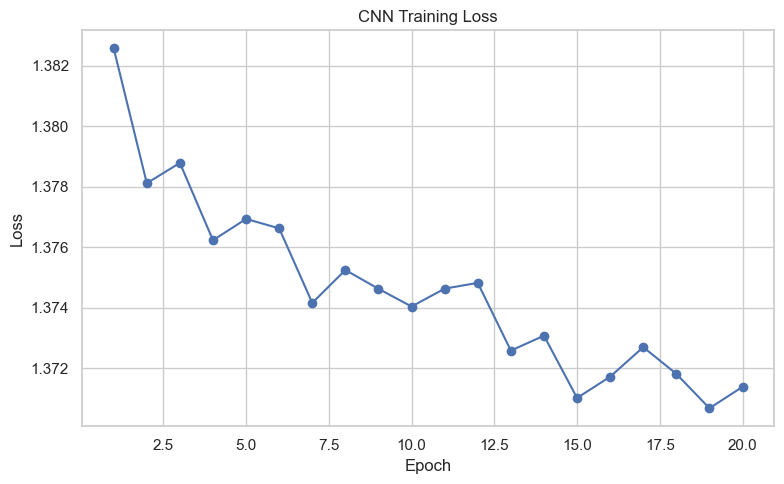


CNN classification report
              precision    recall  f1-score   support

    fatigued       0.08      0.12      0.09       286
   impulsive       0.07      0.17      0.09       259
     careful       0.36      0.22      0.27      1856
     focused       0.50      0.55      0.52      2425

    accuracy                           0.37      4826
   macro avg       0.25      0.26      0.25      4826
weighted avg       0.40      0.37      0.38      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,CNN,0.905305,0.664792,0.335208,0.549109


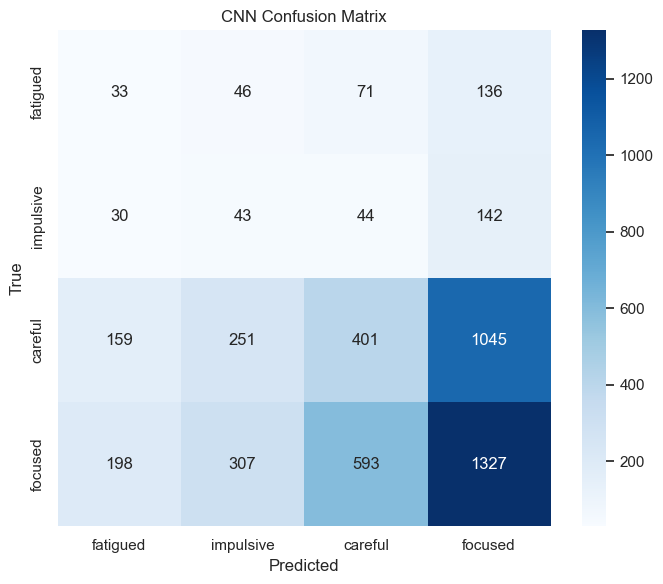

In [19]:
if not TORCH_AVAILABLE:
    print(f"Skipping CNN because PyTorch is unavailable: {TORCH_IMPORT_ERROR}")
else:
    torch.manual_seed(RANDOM_STATE)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training CNN on: {device}")

    train_dataset = EEGFeatureDataset(X_train, y_train)
    test_dataset = EEGFeatureDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=CNN_BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False)

    num_classes = int(np.max(y)) + 1
    cnn = EEGFeatureCNN(num_features=X.shape[1], num_classes=num_classes).to(device)
    present_classes = np.unique(y_train)
    computed_weights = compute_class_weight("balanced", classes=present_classes, y=y_train)
    full_weights = np.ones(num_classes, dtype=np.float32)
    full_weights[present_classes] = computed_weights
    class_weights = torch.tensor(full_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(cnn.parameters(), lr=CNN_LR)

    losses = []
    for epoch in range(1, CNN_EPOCHS + 1):
        loss = train_model(cnn, train_loader, optimizer, criterion, device)
        losses.append(loss)
        if epoch == 1 or epoch % 5 == 0 or epoch == CNN_EPOCHS:
            print(f"Epoch {epoch:>3}/{CNN_EPOCHS} - loss: {loss:.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, CNN_EPOCHS + 1), losses, marker="o")
    ax.set_title("CNN Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    plt.tight_layout()
    plt.show()

    cnn_true, cnn_pred = evaluate_model(cnn, test_loader, device)
    metrics.append(evaluate_predictions("CNN", cnn_true, cnn_pred))

## 15. Model Comparison

,subset,features,accuracy,balanced_accuracy,macro_f1
4,stft_pre_only,20,0.280564,0.249722,0.213134
8,no_stft_with_covariance,83,0.289681,0.249334,0.222063
2,aggregate_no_stft,83,0.289681,0.249334,0.222063
0,all_features,183,0.293203,0.245049,0.216470
1,no_gamma_features,155,0.303978,0.241595,0.218142
3,stft_only,100,0.301699,0.235887,0.202123
5,stft_no_gamma,80,0.302321,0.233171,0.200887
7,covariance_only,10,0.243266,0.228276,0.194707
6,relative_power_only,20,0.252797,0.218401,0.190740


,feature,family,mutual_info
44,AF7_theta,spectral,0.013731
102,AF8_complexity,hjorth,0.011807
39,TP9_tf_gamma_early,time_frequency,0.011576
140,TP10_std,statistical,0.011230
23,TP9_tf_theta_pre,time_frequency,0.010406
122,AF8_tf_beta_early_minus_pre,time_frequency,0.010290
17,TP9_theta_beta_ratio,spectral,0.009453
51,AF7_rel_beta,spectral,0.008987
73,AF7_tf_alpha_late,time_frequency,0.008673
143,TP10_activity,hjorth,0.008466


,family,mutual_info
2,hjorth,0.004657
3,spectral,0.003581
0,asymmetry,0.003488
4,statistical,0.003431
5,time_frequency,0.002601
1,covariance,0.002324


,subset,features,accuracy,balanced_accuracy,macro_f1
2,mutual_info_top_80,80,0.280356,0.245258,0.210220
1,mutual_info_top_40,40,0.270617,0.242397,0.201145
0,mutual_info_top_20,20,0.279320,0.239984,0.203653


,model,window,accuracy,balanced_accuracy,macro_f1
15,CNN,3,0.361169,0.254833,0.232068
16,CNN,5,0.385827,0.254401,0.240764
17,CNN,9,0.408620,0.253740,0.241522
10,Decision Tree,5,0.112308,0.251911,0.104186
9,Decision Tree,3,0.122254,0.251003,0.110857
0,Majority Baseline,3,0.502487,0.250000,0.167218
1,Majority Baseline,5,0.502487,0.250000,0.167218
2,Majority Baseline,9,0.502487,0.250000,0.167218
6,Random Forest,3,0.452549,0.246240,0.232311
12,Gaussian HMM,3,0.426855,0.245894,0.200671


...

,heldout_subject,model,accuracy,balanced_accuracy,macro_f1
11,Experiment_2/B10,Logistic Regression,0.341511,0.324307,0.271755
2,Experiment_1/A2,Logistic Regression,0.373723,0.316644,0.267839
4,Experiment_1/A4,Logistic Regression,0.273057,0.282151,0.232838
18,Experiment_2/B8,Logistic Regression,0.291151,0.278943,0.204448
17,Experiment_2/B7,Logistic Regression,0.297747,0.275994,0.224242
14,Experiment_2/B4,Logistic Regression,0.298839,0.269395,0.227876
19,Experiment_2/B9,Logistic Regression,0.329461,0.268501,0.231600
16,Experiment_2/B6,Logistic Regression,0.317460,0.268395,0.226604
12,Experiment_2/B2,Logistic Regression,0.225837,0.267713,0.171390
0,Experiment_1/A1,Logistic Regression,0.289680,0.265629,0.208220


accuracy           balanced_accuracy            macro_f1  \
                         mean       std              mean       std      mean   
model                                                                           
Logistic Regression  0.286429  0.047307          0.261947  0.026737  0.214099   

                               
                          std  
model                          
Logistic Regression  0.029133

,subject_id,task,feature_subset,accuracy,balanced_accuracy,macro_f1
39,Experiment_1/A9,focused_vs_careful_correct_only,all_features,0.707237,0.694697,0.669270
35,Experiment_1/A8,focused_vs_careful_correct_only,all_features,0.704403,0.675565,0.642867
47,Experiment_2/B10,focused_vs_careful_correct_only,all_features,0.634361,0.631222,0.626948
11,Experiment_1/A2,focused_vs_careful_correct_only,all_features,0.628571,0.627785,0.627836
7,Experiment_1/A10,focused_vs_careful_correct_only,all_features,0.622581,0.622884,0.622105
...,...,...,...,...,...,...
30,Experiment_1/A7,four_class,stft_pre_only,0.277937,0.271170,0.234368
10,Experiment_1/A2,four_class,stft_pre_only,0.285714,0.252432,0.218018
22,Experiment_1/A5,four_class,stft_pre_only,0.300578,0.241093,0.210476
34,Experiment_1/A8,four_class,stft_pre_only,0.292754,0.209997,0.189424


accuracy            \
                                                       mean       std   
task                            feature_subset                          
focused_vs_careful_correct_only all_features       0.607973  0.046052   
four_class                      aggregate_no_stft  0.373584  0.045295   
                                all_features       0.416523  0.061060   
                                stft_pre_only      0.292479  0.030088   

                                                  balanced_accuracy            \
                                                               mean       std   
task                            feature_subset                                  
focused_vs_careful_correct_only all_features               0.601470  0.041384   
four_class                      aggregate_no_stft          0.335560  0.055661   
                                all_features               0.342721  0.046200   
                                stft_pre_only              0.296938  0.048725   

                                                   macro_f1            
                                                       mean       std  
task                            feature_subset                         
focused_vs_careful_correct_only all_features       0.594592  0.036499  
four_class                      aggregate_no_stft  0.279982  0.032958  
                                all_features       0.301957  0.037476  
                                stft_pre_only      0.232479  0.023649

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mean_abs_label_error,adjacent_error_rate,large_jump_error_rate,prediction_majority_rate
5,CNN,0.373809,0.261170,0.245463,0.377438,0.905305,0.664792,0.335208,0.549109
2,Random Forest,0.464360,0.254945,0.242572,0.429516,0.668462,0.827079,0.172921,0.656030
1,Logistic Regression,0.293203,0.245049,0.216470,0.328700,1.159760,0.540018,0.459982,0.391629
4,Gaussian HMM,0.423125,0.249734,0.213847,0.358234,0.878160,0.646911,0.353089,0.770410
0,Majority Baseline,0.502487,0.250000,0.167218,0.336100,0.669706,0.773011,0.226989,1.000000
3,Decision Tree,0.152093,0.238676,0.134669,0.177799,1.622669,0.335044,0.664956,0.410899


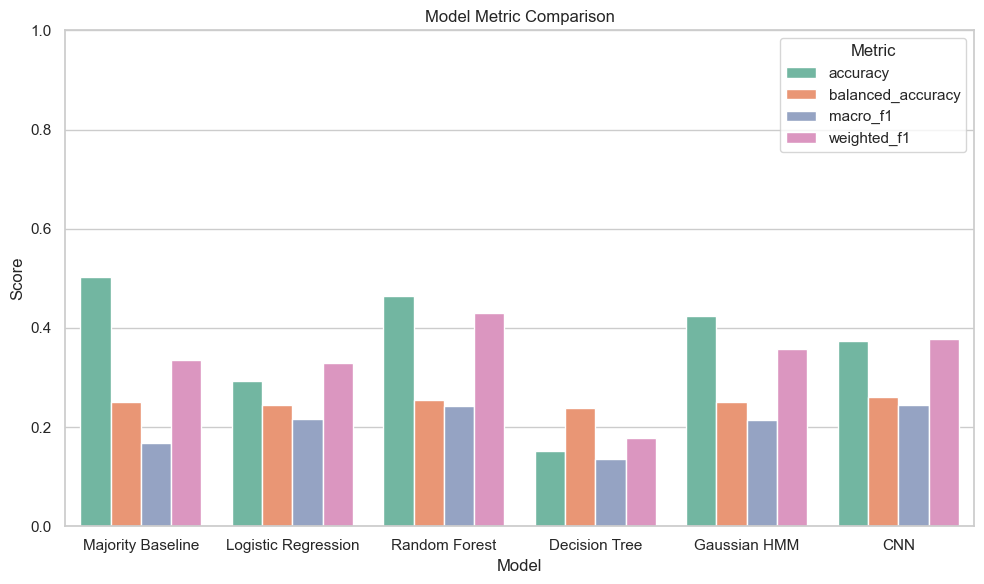

In [20]:
# Extra diagnostics: test whether the EEG features can learn simpler label axes
# and whether one held-out-subject split is hiding fold-to-fold instability.
train_mask = np.zeros(len(y), dtype=bool)
test_mask = np.zeros(len(y), dtype=bool)
train_mask[train_idx] = True
test_mask[test_idx] = True


def evaluate_feature_subset(subset_name, indices):
    indices = list(indices)
    if not indices:
        return None

    subset_model = LogisticRegression(
        C=0.25,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    subset_model.fit(X_train[:, indices], y_train)
    subset_pred = subset_model.predict(X_test[:, indices])
    return {
        "subset": subset_name,
        "features": len(indices),
        "accuracy": accuracy_score(y_test, subset_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, subset_pred),
        "macro_f1": f1_score(y_test, subset_pred, average="macro", zero_division=0),
    }


subset_specs = {
    "all_features": range(len(feature_names)),
    "no_gamma_features": [idx for idx, name in enumerate(feature_names) if "gamma" not in name],
    "aggregate_no_stft": [idx for idx, name in enumerate(feature_names) if feature_family(name) != "time_frequency"],
    "stft_only": [idx for idx, name in enumerate(feature_names) if feature_family(name) == "time_frequency"],
    "stft_pre_only": [idx for idx, name in enumerate(feature_names) if "_tf_" in name and name.endswith("_pre") and "minus" not in name],
    "stft_no_gamma": [idx for idx, name in enumerate(feature_names) if feature_family(name) == "time_frequency" and "gamma" not in name],
    "relative_power_only": [idx for idx, name in enumerate(feature_names) if "_rel_" in name],
    "covariance_only": [idx for idx, name in enumerate(feature_names) if feature_family(name) == "covariance"],
    "no_stft_with_covariance": [idx for idx, name in enumerate(feature_names) if feature_family(name) != "time_frequency"],
}
subset_df = pd.DataFrame([
    row for row in (evaluate_feature_subset(name, indices) for name, indices in subset_specs.items())
    if row is not None
]).sort_values("balanced_accuracy", ascending=False)
display(subset_df)


mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({
    "feature": feature_names,
    "family": [feature_family(name) for name in feature_names],
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=False)
display(mi_df.head(25))
display(mi_df.groupby("family", as_index=False)["mutual_info"].mean().sort_values("mutual_info", ascending=False))

mi_rows = []
for k in [20, 40, 80]:
    k = min(k, len(feature_names))
    top_indices = mi_df.head(k).index.to_numpy()
    row = evaluate_feature_subset(f"mutual_info_top_{k}", top_indices)
    if row is not None:
        mi_rows.append(row)

if RUN_RFE_DIAGNOSTICS:
    rfe_estimator = LogisticRegression(
        C=0.25,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    rfe = RFE(
        estimator=rfe_estimator,
        n_features_to_select=min(40, len(feature_names)),
        step=0.2,
    )
    rfe.fit(X_train, y_train)
    rfe_indices = np.where(rfe.support_)[0]
    rfe_row = evaluate_feature_subset("rfe_top_40", rfe_indices)
    if rfe_row is not None:
        mi_rows.append(rfe_row)

feature_selection_df = pd.DataFrame(mi_rows).sort_values("balanced_accuracy", ascending=False)
display(feature_selection_df)


def majority_vote_smooth(predictions, metadata, window=5):
    predictions = np.asarray(predictions, dtype=np.int32)
    smoothed = predictions.copy()
    if metadata is None or len(metadata) != len(predictions):
        return smoothed

    group_cols = [col for col in ["subject_id", "session"] if col in metadata.columns]
    if not group_cols:
        group_cols = ["__all__"]
        metadata = metadata.copy()
        metadata["__all__"] = "all"

    half_window = max(1, window // 2)
    for _, group in metadata.groupby(group_cols, sort=False):
        positions = group.index.to_numpy()
        if "onset_time_ms" in group.columns:
            order = positions[np.argsort(group["onset_time_ms"].to_numpy())]
        else:
            order = positions

        for local_idx, position in enumerate(order):
            start = max(0, local_idx - half_window)
            end = min(len(order), local_idx + half_window + 1)
            votes = predictions[order[start:end]]
            counts = np.bincount(votes, minlength=len(LABEL_NAMES))
            smoothed[position] = int(np.argmax(counts))

    return smoothed


if trial_metadata is not None and len(trial_metadata) == len(y) and prediction_records:
    test_metadata = trial_metadata.iloc[test_idx].reset_index(drop=True)
    smoothing_rows = []
    for record in prediction_records:
        for window in [3, 5, 9]:
            smoothed_pred = majority_vote_smooth(record["y_pred"], test_metadata, window=window)
            smoothing_rows.append({
                "model": record["model"],
                "window": window,
                "accuracy": accuracy_score(record["y_true"], smoothed_pred),
                "balanced_accuracy": balanced_accuracy_score(record["y_true"], smoothed_pred),
                "macro_f1": f1_score(record["y_true"], smoothed_pred, average="macro", zero_division=0),
            })

    smoothing_df = pd.DataFrame(smoothing_rows).sort_values("balanced_accuracy", ascending=False)
    display(smoothing_df)


def evaluate_binary_task(task_name, binary_target, valid_mask=None):
    if valid_mask is None:
        valid_mask = np.ones(len(y), dtype=bool)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    binary_target = np.asarray(binary_target, dtype=np.int32)

    task_train = train_mask & valid_mask
    task_test = test_mask & valid_mask
    if task_train.sum() == 0 or task_test.sum() == 0:
        return None
    if len(np.unique(binary_target[task_train])) < 2 or len(np.unique(binary_target[task_test])) < 2:
        return None

    task_scaler = StandardScaler()
    X_task_train = task_scaler.fit_transform(X_model[task_train])
    X_task_test = task_scaler.transform(X_model[task_test])
    y_task_train = binary_target[task_train]
    y_task_test = binary_target[task_test]

    model = LogisticRegression(
        C=0.25,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    model.fit(X_task_train, y_task_train)
    pred = model.predict(X_task_test)

    baseline = DummyClassifier(strategy="most_frequent")
    baseline.fit(X_task_train, y_task_train)
    baseline_pred = baseline.predict(X_task_test)

    return {
        "task": task_name,
        "train_samples": int(task_train.sum()),
        "test_samples": int(task_test.sum()),
        "positive_rate_test": float(np.mean(y_task_test)),
        "model_accuracy": accuracy_score(y_task_test, pred),
        "model_balanced_accuracy": balanced_accuracy_score(y_task_test, pred),
        "model_macro_f1": f1_score(y_task_test, pred, average="macro", zero_division=0),
        "baseline_accuracy": accuracy_score(y_task_test, baseline_pred),
        "baseline_balanced_accuracy": balanced_accuracy_score(y_task_test, baseline_pred),
    }


if RUN_BINARY_DIAGNOSTICS:
    binary_rows = []
    binary_rows.append(evaluate_binary_task("fast_vs_slow_all_trials", np.isin(y, [1, 3]).astype(int)))
    binary_rows.append(evaluate_binary_task("correct_vs_incorrect_all_trials", np.isin(y, [2, 3]).astype(int)))
    correct_mask = np.isin(y, [2, 3])
    binary_rows.append(evaluate_binary_task("focused_vs_careful_correct_only", (y == 3).astype(int), correct_mask))
    incorrect_mask = np.isin(y, [0, 1])
    binary_rows.append(evaluate_binary_task("impulsive_vs_fatigued_incorrect_only", (y == 1).astype(int), incorrect_mask))
    binary_df = pd.DataFrame([row for row in binary_rows if row is not None])
    display(binary_df)


if RUN_LOSO_DIAGNOSTICS and subject_ids is not None and len(subject_ids) == len(y):
    loso_rows = []
    logo = LeaveOneGroupOut()
    for fold_train_idx, fold_test_idx in logo.split(X_model, y, groups=subject_ids):
        heldout_subject = subject_ids[fold_test_idx][0]
        fold_scaler = StandardScaler()
        X_fold_train = fold_scaler.fit_transform(X_model[fold_train_idx])
        X_fold_test = fold_scaler.transform(X_model[fold_test_idx])

        fold_model = LogisticRegression(
            C=0.25,
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
        fold_model.fit(X_fold_train, y[fold_train_idx])
        fold_pred = fold_model.predict(X_fold_test)
        loso_rows.append({
            "heldout_subject": heldout_subject,
            "model": "Logistic Regression",
            "accuracy": accuracy_score(y[fold_test_idx], fold_pred),
            "balanced_accuracy": balanced_accuracy_score(y[fold_test_idx], fold_pred),
            "macro_f1": f1_score(y[fold_test_idx], fold_pred, average="macro", zero_division=0),
        })

        if RUN_LOSO_RANDOM_FOREST:
            fold_forest = RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_split=20,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            fold_forest.fit(X_fold_train, y[fold_train_idx])
            fold_forest_pred = fold_forest.predict(X_fold_test)
            loso_rows.append({
                "heldout_subject": heldout_subject,
                "model": "Random Forest",
                "accuracy": accuracy_score(y[fold_test_idx], fold_forest_pred),
                "balanced_accuracy": balanced_accuracy_score(y[fold_test_idx], fold_forest_pred),
                "macro_f1": f1_score(y[fold_test_idx], fold_forest_pred, average="macro", zero_division=0),
            })

    loso_df = pd.DataFrame(loso_rows).sort_values(["model", "balanced_accuracy"], ascending=[True, False])
    display(loso_df)
    display(loso_df.groupby("model")[["accuracy", "balanced_accuracy", "macro_f1"]].agg(["mean", "std"]))


if RUN_PERSON_SPECIFIC_DIAGNOSTICS and subject_ids is not None and len(subject_ids) == len(y):
    person_rows = []
    subset_indices = {
        "all_features": np.arange(len(feature_names)),
        "aggregate_no_stft": np.array([
            idx for idx, name in enumerate(feature_names)
            if feature_family(name) != "time_frequency"
        ]),
        "stft_pre_only": np.array([
            idx for idx, name in enumerate(feature_names)
            if "_tf_" in name and name.endswith("_pre") and "minus" not in name
        ]),
    }

    for subject in sorted(np.unique(subject_ids)):
        subject_mask = subject_ids == subject
        subject_y = y[subject_mask]
        class_counts = pd.Series(subject_y).value_counts()
        if len(class_counts) < 4 or class_counts.min() < 3:
            continue

        splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
        subject_indices = np.where(subject_mask)[0]
        local_train, local_test = next(splitter.split(X[subject_indices], subject_y))
        subject_train_idx = subject_indices[local_train]
        subject_test_idx = subject_indices[local_test]

        for subset_name, indices in subset_indices.items():
            scaler_subject = StandardScaler()
            X_subject_train = scaler_subject.fit_transform(X[subject_train_idx][:, indices])
            X_subject_test = scaler_subject.transform(X[subject_test_idx][:, indices])

            model_subject = LogisticRegression(
                C=0.25,
                max_iter=5000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
            model_subject.fit(X_subject_train, y[subject_train_idx])
            pred_subject = model_subject.predict(X_subject_test)
            person_rows.append({
                "subject_id": subject,
                "task": "four_class",
                "feature_subset": subset_name,
                "accuracy": accuracy_score(y[subject_test_idx], pred_subject),
                "balanced_accuracy": balanced_accuracy_score(y[subject_test_idx], pred_subject),
                "macro_f1": f1_score(y[subject_test_idx], pred_subject, average="macro", zero_division=0),
            })

        correct_subject_idx = subject_indices[np.isin(subject_y, [2, 3])]
        correct_y = (y[correct_subject_idx] == 3).astype(int)
        correct_counts = pd.Series(correct_y).value_counts()
        if len(correct_counts) == 2 and correct_counts.min() >= 3:
            local_train, local_test = next(splitter.split(X[correct_subject_idx], correct_y))
            correct_train_idx = correct_subject_idx[local_train]
            correct_test_idx = correct_subject_idx[local_test]

            scaler_correct = StandardScaler()
            X_correct_train = scaler_correct.fit_transform(X[correct_train_idx])
            X_correct_test = scaler_correct.transform(X[correct_test_idx])

            model_correct = LogisticRegression(
                C=0.25,
                max_iter=5000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
            model_correct.fit(X_correct_train, correct_y[local_train])
            pred_correct = model_correct.predict(X_correct_test)
            person_rows.append({
                "subject_id": subject,
                "task": "focused_vs_careful_correct_only",
                "feature_subset": "all_features",
                "accuracy": accuracy_score(correct_y[local_test], pred_correct),
                "balanced_accuracy": balanced_accuracy_score(correct_y[local_test], pred_correct),
                "macro_f1": f1_score(correct_y[local_test], pred_correct, average="macro", zero_division=0),
            })

    person_df = pd.DataFrame(person_rows)
    display(person_df.sort_values(["task", "feature_subset", "balanced_accuracy"], ascending=[True, True, False]))
    display(person_df.groupby(["task", "feature_subset"])[["accuracy", "balanced_accuracy", "macro_f1"]].agg(["mean", "std"]))


metrics_df = pd.DataFrame([
    {
        "model": item["model"],
        "accuracy": item["accuracy"],
        "balanced_accuracy": item["balanced_accuracy"],
        "macro_f1": item["macro_f1"],
        "weighted_f1": item["weighted_f1"],
        "mean_abs_label_error": item["mean_abs_label_error"],
        "adjacent_error_rate": item["adjacent_error_rate"],
        "large_jump_error_rate": item["large_jump_error_rate"],
        "prediction_majority_rate": item["prediction_majority_rate"],
    }
    for item in metrics
])

display(metrics_df.sort_values("macro_f1", ascending=False))

if not metrics_df.empty:
    plot_metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
    plot_df = metrics_df[["model"] + plot_metric_cols].melt(id_vars="model", var_name="metric", value_name="score")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=plot_df, x="model", y="score", hue="metric", ax=ax, palette="Set2")
    ax.set_title("Model Metric Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.show()
else:
    print("No model metrics were collected.")

### CNN, HMM, and Decision Tree Metric Charts

,model,macro_f1,accuracy,macro_precision
2,CNN,0.245463,0.373809,0.251843
1,HMM,0.213847,0.423125,0.245880
0,Decision Tree,0.134669,0.152093,0.232782


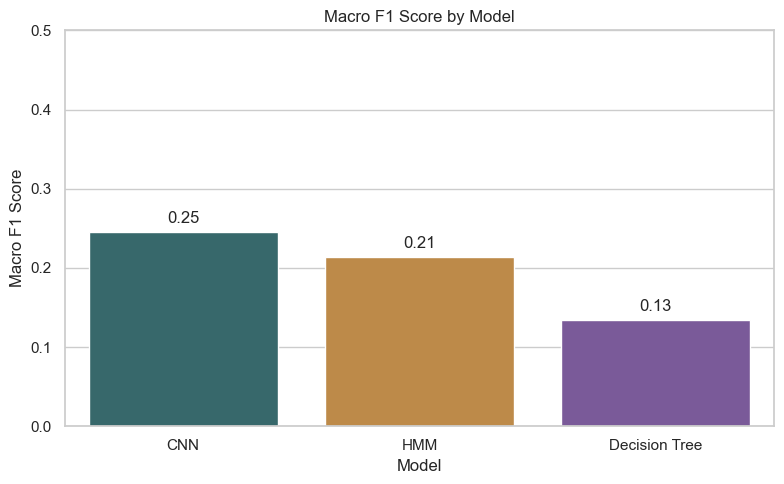

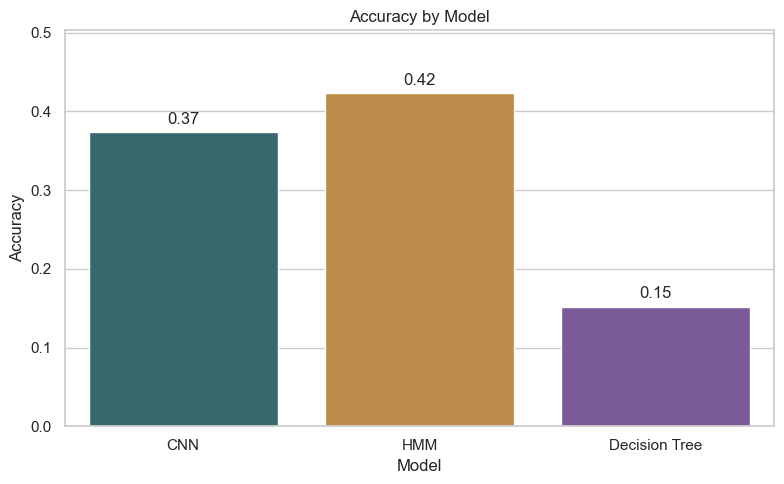

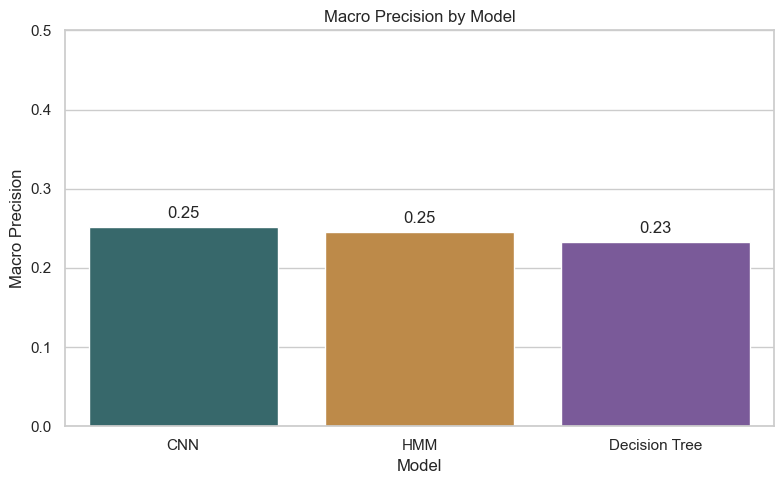

In [21]:
selected_models = ["CNN", "Gaussian HMM", "Decision Tree"]

chart_rows = []
for item in metrics:
    if item["model"] not in selected_models:
        continue

    chart_rows.append({
        "model": "HMM" if item["model"] == "Gaussian HMM" else item["model"],
        "macro_f1": item["macro_f1"],
        "accuracy": item["accuracy"],
        "macro_precision": item["report"]["macro avg"]["precision"],
    })

chart_df = pd.DataFrame(chart_rows)
model_order = ["CNN", "HMM", "Decision Tree"]
chart_df["model"] = pd.Categorical(chart_df["model"], categories=model_order, ordered=True)
chart_df = chart_df.sort_values("model")

display(chart_df)


def plot_model_metric(metric, title, ylabel, output_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=chart_df,
        x="model",
        y=metric,
        hue="model",
        order=model_order,
        palette=["#2f6f73", "#d08c36", "#7b4fa3"],
        legend=False,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(0.5, chart_df[metric].max() + 0.08))

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=4)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_model_metric(
    metric="macro_f1",
    title="Macro F1 Score by Model",
    ylabel="Macro F1 Score",
    output_path="f1_score_comparison.png",
)
plot_model_metric(
    metric="accuracy",
    title="Accuracy by Model",
    ylabel="Accuracy",
    output_path="accuracy_comparison.png",
)
plot_model_metric(
    metric="macro_precision",
    title="Macro Precision by Model",
    ylabel="Macro Precision",
    output_path="precision_comparison.png",
)


Loaded static features from c:\Users\Chris\.vscode\Repositories\AI-Interpretation-on-Cognitive-States\Data\processed\static_features.csv with shape (24037, 31)

Static Optimized Random Forest classification report
              precision    recall  f1-score   support

    fatigued       0.06      0.05      0.06       286
   impulsive       0.09      0.07      0.08       259
     careful       0.42      0.48      0.45      1856
     focused       0.53      0.48      0.50      2425

    accuracy                           0.44      4826
   macro avg       0.27      0.27      0.27      4826
weighted avg       0.43      0.44      0.43      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Static Optimized Random Forest,0.758392,0.746696,0.253304,0.458143


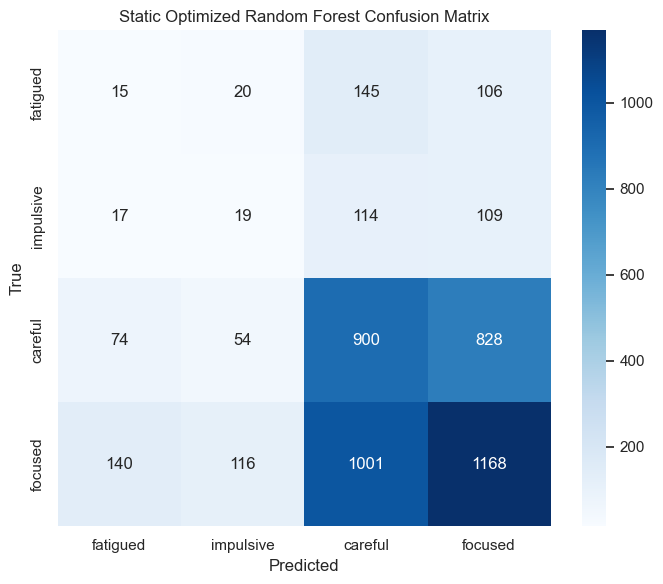


Static Gaussian HMM classification report
              precision    recall  f1-score   support

    fatigued       0.00      0.00      0.00       286
   impulsive       0.11      0.04      0.06       259
     careful       0.39      0.98      0.56      1856
     focused       0.57      0.01      0.02      2425

    accuracy                           0.38      4826
   macro avg       0.27      0.26      0.16      4826
weighted avg       0.44      0.38      0.23      4826



,model,mean_abs_label_error,adjacent_error_rate_among_errors,large_jump_error_rate_among_errors,prediction_majority_rate
0,Static Gaussian HMM,0.687319,0.887021,0.112979,0.970783


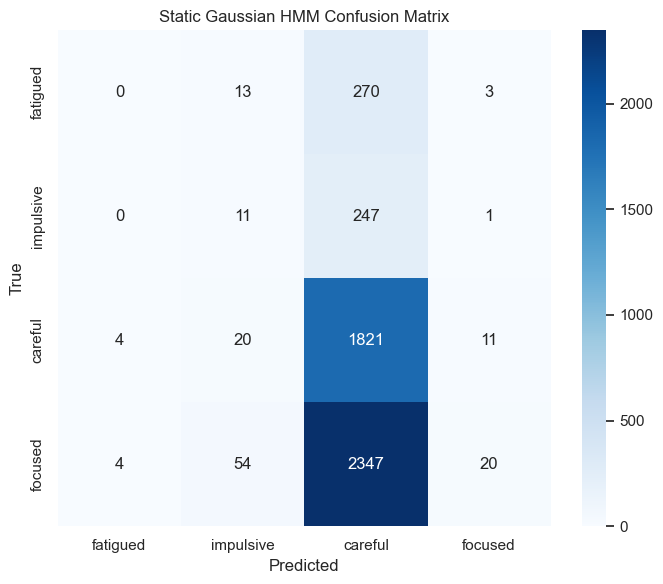

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,mean_abs_label_error,adjacent_error_rate,large_jump_error_rate,prediction_majority_rate
0,Static Optimized Random Forest,0.435557,0.273092,0.272419,0.433267,0.758392,0.746696,0.253304,0.458143
1,Static Gaussian HMM,0.383755,0.257965,0.158670,0.225612,0.687319,0.887021,0.112979,0.970783


,feature,importance
1,fft_spectral_entropy,0.052691
6,skew,0.050116
2,ewma_residual_max,0.050050
9,num_large_jumps,0.049203
17,max,0.048610
13,fft_high_freq_power_ratio,0.047942
0,spectral_flatness,0.046960
5,fft_low_freq_power_ratio,0.046543
8,cusum_range,0.045738
19,max_abs_change,0.045577


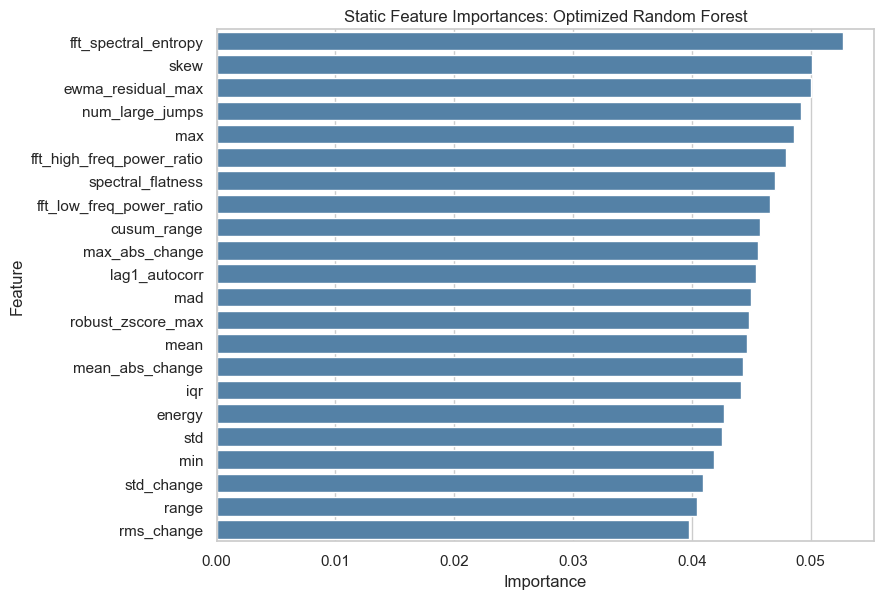

In [22]:
# Static feature benchmark: optimized Random Forest and Gaussian HMM
# Expected input: Data/processed/static_features.csv or .parquet with one row per sample.
# The preferred alignment is the same row order as y_labels.npy / the current notebook y array.

from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew as scipy_skew

STATIC_FEATURE_COLUMNS = [
    "spectral_flatness",
    "fft_spectral_entropy",
    "ewma_residual_max",
    "std_change",
    "rms_change",
    "fft_low_freq_power_ratio",
    "skew",
    "std",
    "cusum_range",
    "num_large_jumps",
    "mean",
    "robust_zscore_max",
    "mad",
    "fft_high_freq_power_ratio",
    "iqr",
    "lag1_autocorr",
    "mean_abs_change",
    "max",
    "range",
    "max_abs_change",
    "min",
    "energy",
]

REBUILD_STATIC_FEATURES = False

def extract_static_features_1d(data, fs=256):
    data = np.asarray(data, dtype=np.float64)
    data = data[np.isfinite(data)]
    if len(data) < 4:
        return {name: 0.0 for name in STATIC_FEATURE_COLUMNS}

    eps = 1e-12
    centered = data - np.mean(data)
    diffs = np.diff(data)
    abs_diffs = np.abs(diffs) if len(diffs) > 0 else np.array([0.0])
    median = float(np.median(data))
    mad = float(np.median(np.abs(data - median)))
    robust_scale = max(1.4826 * mad, eps)
    q25, q75 = np.percentile(data, [25, 75])

    ewma = pd.Series(data).ewm(alpha=0.15, adjust=False).mean().to_numpy()
    ewma_residual = data - ewma
    jump_threshold = np.median(abs_diffs) + 3.0 * np.median(np.abs(abs_diffs - np.median(abs_diffs)))

    windowed = centered * np.hanning(len(centered))
    fft_values = np.fft.rfft(windowed)
    fft_freqs = np.fft.rfftfreq(len(windowed), d=1.0 / fs)
    fft_power = np.abs(fft_values) ** 2
    valid = fft_freqs > 0
    fft_freqs = fft_freqs[valid]
    fft_power = fft_power[valid]
    total_fft_power = float(np.sum(fft_power))
    if total_fft_power > eps and len(fft_power) > 1:
        power_probs = fft_power / total_fft_power
        fft_spectral_entropy = float(-np.sum(power_probs * np.log(power_probs + eps)) / np.log(len(power_probs)))
        spectral_flatness = float(np.exp(np.mean(np.log(fft_power + eps))) / (np.mean(fft_power) + eps))
        low_mask = (fft_freqs >= 0.5) & (fft_freqs < 8.0)
        high_mask = (fft_freqs >= 13.0) & (fft_freqs <= 45.0)
        fft_low_freq_power_ratio = float(np.sum(fft_power[low_mask]) / (total_fft_power + eps))
        fft_high_freq_power_ratio = float(np.sum(fft_power[high_mask]) / (total_fft_power + eps))
    else:
        fft_spectral_entropy = 0.0
        spectral_flatness = 0.0
        fft_low_freq_power_ratio = 0.0
        fft_high_freq_power_ratio = 0.0

    if len(data) > 2 and np.std(data[:-1]) > eps and np.std(data[1:]) > eps:
        lag1_autocorr = float(np.corrcoef(data[:-1], data[1:])[0, 1])
    else:
        lag1_autocorr = 0.0

    return {
        "spectral_flatness": spectral_flatness,
        "fft_spectral_entropy": fft_spectral_entropy,
        "ewma_residual_max": float(np.max(np.abs(ewma_residual))),
        "std_change": float(np.std(diffs)) if len(diffs) else 0.0,
        "rms_change": float(np.sqrt(np.mean(diffs ** 2))) if len(diffs) else 0.0,
        "fft_low_freq_power_ratio": fft_low_freq_power_ratio,
        "skew": float(scipy_skew(data)) if len(data) > 2 else 0.0,
        "std": float(np.std(data)),
        "cusum_range": float(np.ptp(np.cumsum(centered))),
        "num_large_jumps": float(np.sum(abs_diffs > jump_threshold)) / max(1, len(abs_diffs)),
        "mean": float(np.mean(data)),
        "robust_zscore_max": float(np.max(np.abs(data - median) / robust_scale)),
        "mad": mad,
        "fft_high_freq_power_ratio": fft_high_freq_power_ratio,
        "iqr": float(q75 - q25),
        "lag1_autocorr": lag1_autocorr,
        "mean_abs_change": float(np.mean(abs_diffs)),
        "max": float(np.max(data)),
        "range": float(np.ptp(data)),
        "max_abs_change": float(np.max(abs_diffs)),
        "min": float(np.min(data)),
        "energy": float(np.mean(centered ** 2)),
    }


def extract_static_window_features(eeg_window, preprocessor):
    channel_features = []
    for channel in preprocessor.eeg_channels:
        if channel not in eeg_window.columns:
            continue
        cleaned = preprocessor.clean_eeg_channel(eeg_window[channel].dropna().values)
        if len(cleaned) < 4:
            continue
        channel_features.append(extract_static_features_1d(cleaned, fs=preprocessor.eeg_sampling_rate))

    if not channel_features:
        return None

    return {
        feature: float(np.mean([row[feature] for row in channel_features]))
        for feature in STATIC_FEATURE_COLUMNS
    }


def build_static_feature_table(raw_dir=DATA_RAW, experiments=EXPERIMENTS):
    preprocessor = EEGPreprocessor(str(raw_dir))
    rows = []

    for experiment in experiments:
        subjects = discover_subjects(raw_dir, experiment)
        print(f"\nBuilding static features for {experiment}: {len(subjects)} subjects")
        for subject in subjects:
            behavior_df = preprocessor.load_behavioral_data(subject, experiment)
            if behavior_df is None:
                continue
            trial_df = preprocessor.extract_trial_data(behavior_df)
            if trial_df is None or len(trial_df) == 0:
                continue
            trial_df, _ = preprocessor.create_labels(trial_df)

            eeg_df = preprocessor.load_eeg(subject, experiment)
            if eeg_df is None:
                continue

            kept = 0
            for idx, trial in trial_df.iterrows():
                eeg_window = preprocessor.get_eeg_window(
                    eeg_df,
                    trial["onset_time_ms"],
                    behavior_start_unix=trial.get("behavior_start_unix", None),
                    window_before_ms=500,
                    window_after_ms=2000,
                )
                if eeg_window is None or len(eeg_window) < 16:
                    continue
                feature_row = extract_static_window_features(eeg_window, preprocessor)
                if feature_row is None:
                    continue

                feature_row.update({
                    "label": int(trial["cognitive_state"]),
                    "state_label": trial.get("state_label", np.nan),
                    "experiment": experiment,
                    "subject": subject,
                    "subject_id": f"{experiment}/{subject}",
                    "session": trial.get("session", np.nan),
                    "condition": trial.get("condition", np.nan),
                    "instruction": trial.get("instruction", np.nan),
                    "trial": trial.get("trial", np.nan),
                })
                rows.append(feature_row)
                kept += 1
            print(f"  {experiment}/{subject}: {kept} static feature rows")

    if not rows:
        raise RuntimeError("No static feature rows were extracted from the raw EEG data.")

    static_table = pd.DataFrame(rows)
    static_table.to_csv(DATA_PROCESSED / "static_features.csv", index=False)
    print(f"Saved static features to {DATA_PROCESSED / 'static_features.csv'} with shape {static_table.shape}")
    return static_table

static_candidates = [
    DATA_PROCESSED / "static_features.csv",
    DATA_PROCESSED / "static_feature_table.csv",
    DATA_PROCESSED / "static_features.parquet",
]

static_df = None
static_source = None
for candidate in static_candidates:
    if candidate.exists():
        static_source = candidate
        if candidate.suffix.lower() == ".parquet":
            static_df = pd.read_parquet(candidate)
        else:
            static_df = pd.read_csv(candidate)
        break

static_label_candidates = ["label", "y", "state", "cognitive_state"]
needs_static_rebuild = (
    static_df is None
    or REBUILD_STATIC_FEATURES
    or any(col not in static_df.columns for col in STATIC_FEATURE_COLUMNS)
    or (
        "y" in globals()
        and len(static_df) != len(y)
        and not any(col in static_df.columns for col in static_label_candidates)
    )
)

if needs_static_rebuild:
    if static_df is None:
        print("No static feature table found; extracting static features from aligned raw EEG windows.")
    elif REBUILD_STATIC_FEATURES:
        print("REBUILD_STATIC_FEATURES=True; rebuilding static features from aligned raw EEG windows.")
    else:
        missing = [col for col in STATIC_FEATURE_COLUMNS if col not in static_df.columns]
        print(f"Existing static table needs rebuilding. Missing feature columns: {missing}")
    static_df = build_static_feature_table(DATA_RAW, EXPERIMENTS)
    static_source = DATA_PROCESSED / "static_features.csv"

if static_df is not None:
    print(f"Loaded static features from {static_source} with shape {static_df.shape}")

    static_feature_cols = [col for col in STATIC_FEATURE_COLUMNS if col in static_df.columns]
    missing_static_cols = [col for col in STATIC_FEATURE_COLUMNS if col not in static_df.columns]

    if missing_static_cols:
        print(f"Missing {len(missing_static_cols)} requested static features; training with the available requested columns only.")
        print(missing_static_cols)

    if not static_feature_cols:
        print("None of the requested static feature columns were found, so static RF/HMM training was skipped.")
    else:
        static_X_df = static_df[static_feature_cols].apply(pd.to_numeric, errors="coerce")
        static_X_df = static_X_df.replace([np.inf, -np.inf], np.nan)
        static_X_df = static_X_df.fillna(static_X_df.median(numeric_only=True)).fillna(0.0)
        X_static = static_X_df.to_numpy(dtype=np.float32)

        label_column = next((col for col in static_label_candidates if col in static_df.columns), None)
        aligned_with_current_y = "y" in globals() and len(static_df) == len(y)

        if aligned_with_current_y:
            y_static = np.asarray(y)
            static_label_names = LABEL_NAMES if "LABEL_NAMES" in globals() else np.array(sorted(np.unique(y_static)).astype(str))
            if "train_idx" in globals() and "test_idx" in globals():
                static_train_idx = np.asarray(train_idx)
                static_test_idx = np.asarray(test_idx)
            elif globals().get("USE_SUBJECT_HELDOUT_SPLIT", False) and "subject_id" in static_df.columns:
                splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
                static_train_idx, static_test_idx = next(splitter.split(X_static, y_static, groups=static_df["subject_id"].to_numpy()))
            else:
                static_train_idx, static_test_idx = train_test_split(
                    np.arange(len(y_static)),
                    test_size=TEST_SIZE,
                    random_state=RANDOM_STATE,
                    stratify=y_static,
                )
        elif label_column is not None:
            encoder = LabelEncoder()
            y_static = encoder.fit_transform(static_df[label_column].astype(str))
            static_label_names = encoder.classes_
            if globals().get("USE_SUBJECT_HELDOUT_SPLIT", False) and "subject_id" in static_df.columns:
                splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
                static_train_idx, static_test_idx = next(splitter.split(X_static, y_static, groups=static_df["subject_id"].to_numpy()))
            else:
                static_train_idx, static_test_idx = train_test_split(
                    np.arange(len(y_static)),
                    test_size=TEST_SIZE,
                    random_state=RANDOM_STATE,
                    stratify=y_static,
                )
        else:
            y_static = None
            print("Static table is not row-aligned with the notebook labels and has no label column; training was skipped.")

        if y_static is not None:
            X_static_train = X_static[static_train_idx]
            X_static_test = X_static[static_test_idx]
            y_static_train = y_static[static_train_idx]
            y_static_test = y_static[static_test_idx]

            def evaluate_static_predictions(model_name, y_true, y_pred, target_names):
                labels = sorted(np.unique(np.concatenate([y_true, y_pred])).tolist())
                names = [str(target_names[label]) if label < len(target_names) else str(label) for label in labels]
                report_dict = classification_report(
                    y_true,
                    y_pred,
                    labels=labels,
                    target_names=names,
                    output_dict=True,
                    zero_division=0,
                )
                print(f"\n{model_name} classification report")
                print(classification_report(y_true, y_pred, labels=labels, target_names=names, zero_division=0))

                cm = confusion_matrix(y_true, y_pred, labels=labels)
                y_true_array = np.asarray(y_true)
                y_pred_array = np.asarray(y_pred)
                abs_label_error = np.abs(y_true_array - y_pred_array)
                error_mask = y_true_array != y_pred_array
                adjacent_error_rate = float(np.mean(abs_label_error[error_mask] == 1)) if np.any(error_mask) else 0.0
                large_jump_error_rate = float(np.mean(abs_label_error[error_mask] >= 2)) if np.any(error_mask) else 0.0
                mean_abs_label_error = float(np.mean(abs_label_error))
                prediction_majority_rate = float(pd.Series(y_pred_array).value_counts(normalize=True).iloc[0])

                display(pd.DataFrame({
                    "model": [model_name],
                    "mean_abs_label_error": [mean_abs_label_error],
                    "adjacent_error_rate_among_errors": [adjacent_error_rate],
                    "large_jump_error_rate_among_errors": [large_jump_error_rate],
                    "prediction_majority_rate": [prediction_majority_rate],
                }))

                fig, ax = plt.subplots(figsize=(7, 6))
                sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, ax=ax)
                ax.set_title(f"{model_name} Confusion Matrix")
                ax.set_xlabel("Predicted")
                ax.set_ylabel("True")
                plt.tight_layout()
                plt.show()

                return {
                    "model": model_name,
                    "accuracy": accuracy_score(y_true, y_pred),
                    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
                    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
                    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
                    "mean_abs_label_error": mean_abs_label_error,
                    "adjacent_error_rate": adjacent_error_rate,
                    "large_jump_error_rate": large_jump_error_rate,
                    "prediction_majority_rate": prediction_majority_rate,
                    "report": report_dict,
                    "y_true": y_true_array,
                    "y_pred": y_pred_array,
                }

            static_scaler = StandardScaler()
            X_static_train_scaled = static_scaler.fit_transform(X_static_train)
            X_static_test_scaled = static_scaler.transform(X_static_test)

            static_rf = RandomForestClassifier(
                n_estimators=800,
                max_depth=12,
                min_samples_split=20,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            static_rf.fit(X_static_train_scaled, y_static_train)
            static_rf_pred = static_rf.predict(X_static_test_scaled)

            static_hmm = train_state_hmms(
                X_static_train_scaled,
                y_static_train,
                n_components=globals().get("HMM_COMPONENTS", 2),
                random_state=RANDOM_STATE,
            )
            static_hmm_pred = predict_hmm(static_hmm, X_static_test_scaled)

            static_metrics = []
            static_metrics.append(evaluate_static_predictions("Static Optimized Random Forest", y_static_test, static_rf_pred, static_label_names))
            static_metrics.append(evaluate_static_predictions("Static Gaussian HMM", y_static_test, static_hmm_pred, static_label_names))

            static_metrics_df = pd.DataFrame(static_metrics)[[
                "model",
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "weighted_f1",
                "mean_abs_label_error",
                "adjacent_error_rate",
                "large_jump_error_rate",
                "prediction_majority_rate",
            ]]
            display(static_metrics_df.sort_values("macro_f1", ascending=False))

            static_importance_df = pd.DataFrame({
                "feature": static_feature_cols,
                "importance": static_rf.feature_importances_,
            }).sort_values("importance", ascending=False)

            display(static_importance_df)
            fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(static_importance_df))))
            sns.barplot(data=static_importance_df, x="importance", y="feature", ax=ax, color="steelblue")
            ax.set_title("Static Feature Importances: Optimized Random Forest")
            ax.set_xlabel("Importance")
            ax.set_ylabel("Feature")
            plt.tight_layout()
            plt.show()
